![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 4. Process Design Kit (PDK) and Layout

In [145]:
import gdsfactory as gf

## 1. Technology

We will work with the **demo UPVfab PDK**. (There are some other open-source PDKs, in other technologies, feel free to search if interested)

In [146]:
from upvfab.sin300.cband import PDK, cells

Let's view the layer distribution of this PDK. In our case, for the passive devices we will only use the **Layer 1**. 

2026-06-12 15:59:15.477 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


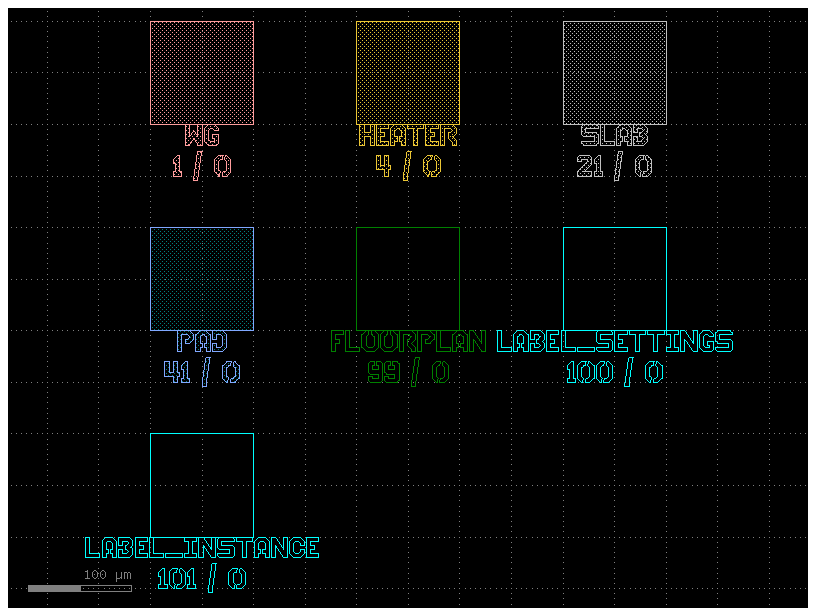

In [147]:
LAYER_VIEWS = PDK.layer_views
c = LAYER_VIEWS.preview_layerset()
c.show()
c.plot()


The new versions of GDS Factory allow to view the Layer Stack also (3D view of the fabrication flow). The following code allows to generate and view the Layer Stack of the generic PDK. Reference: https://www.degruyter.com/document/doi/10.1515/nanoph-2013-0034/html

The layers and the thicknesses have been defined previously on the PDK, so it is possible to view in 3D some of the components in the PDK. 

See the [Reference Manual](https://gdsfactory.github.io/gdsfactory/components.html) and read the list of the available components.

Here are some examples of the 3D views of this photonic components

2026-06-12 15:59:17.235 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


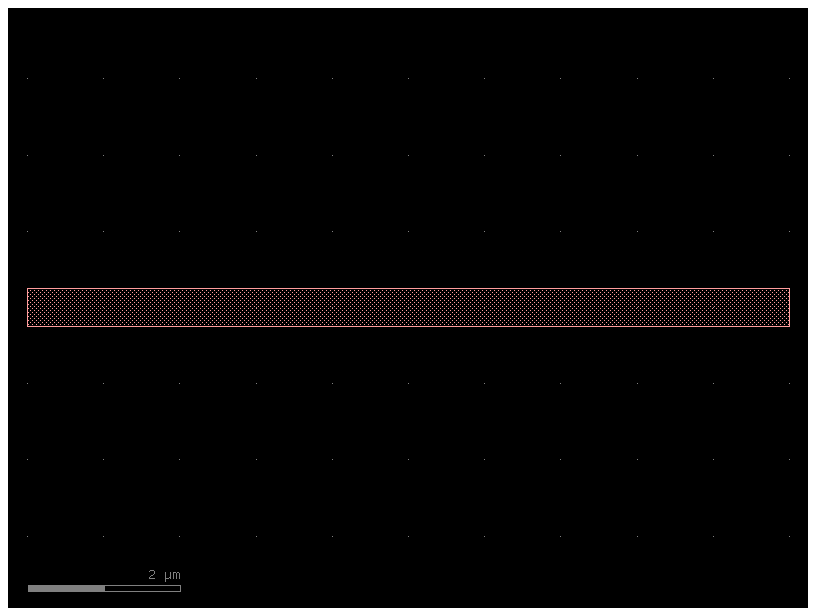

In [148]:
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

c = gf.components.straight(length=10, cross_section=xs)  #Deep 
c.plot() # To view the component on Notebook
c.show() # To view on KLayout
scene = c.to_3d()
scene.show()


2026-06-12 15:59:17.743 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-12 15:59:17.829 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


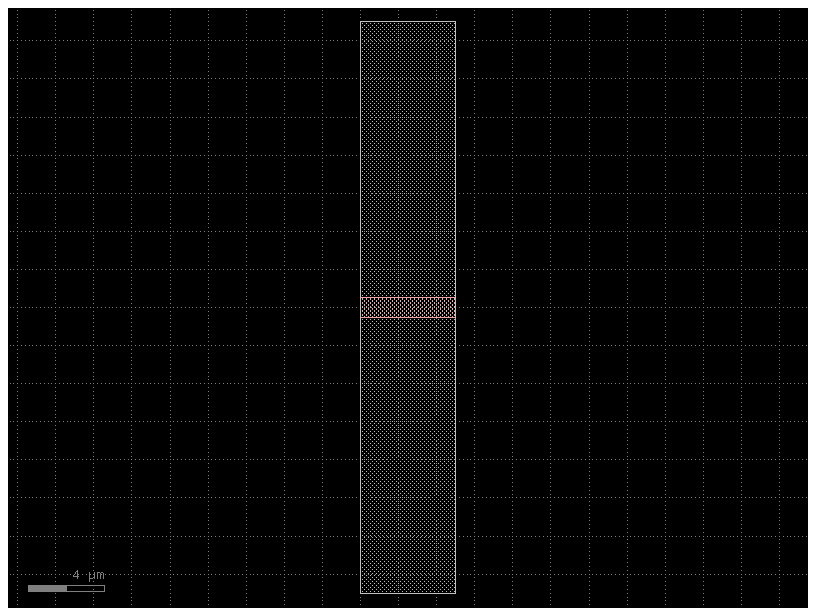

In [149]:
c = gf.components.straight(length=5, cross_section='rib') #Shallow
c.plot()
c.show()

scene = c.to_3d()
c.show()
scene.show()

In [150]:
c = cells.taper_strip_to_ridge(length=10) #Taper
c.show()

scene = c.to_3d()
scene.show()

2026-06-12 15:59:18.643 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


2026-06-12 15:59:19.216 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


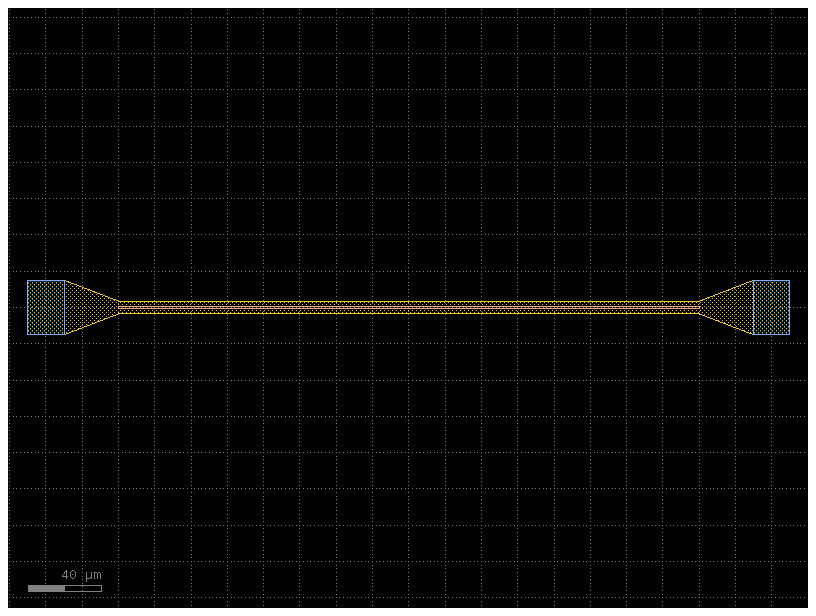

In [151]:
c = cells.straight_heater_metal()

#c.pprint_ports()

c.plot()
c.show()
#c.draw_ports()

scene = c.to_3d()
scene.show()

- Use your design results from Lab2 and Lab3 to create **layout** instances of your designed components: DCs, MMIs, MZIs & Ring Resonators. 

## 2. Layout Fundamentals

A cell is a function that returns a Component. In GDS each component must have a unique name. Two components stored in the GDS file cannot have the same name. They need to be references (instances) of the same component.

![GDSFactoryComponents][def]


[def]: https://i.imgur.com/oeuKGsc.png

2026-06-12 15:59:19.694 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


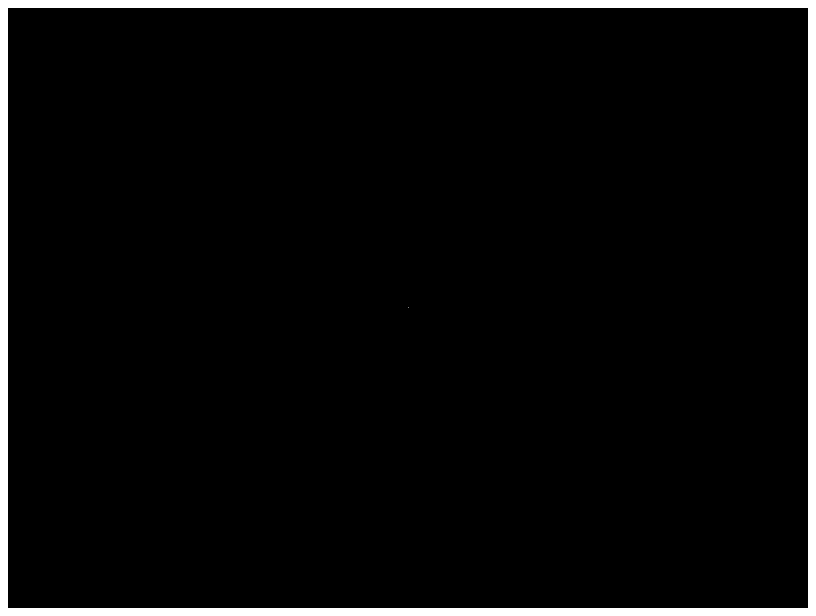

In [152]:
c = gf.Component()
c.plot()
c.show()

Let's build a Component from scratch. A die (chip) for a photonic layout. The PDK or Design Manual should specify the Layer for the bounding box (dicing line). 
We should also consider: 
1. The die dimensions and 
2. The border for dicing 

2026-06-12 15:59:19.949 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


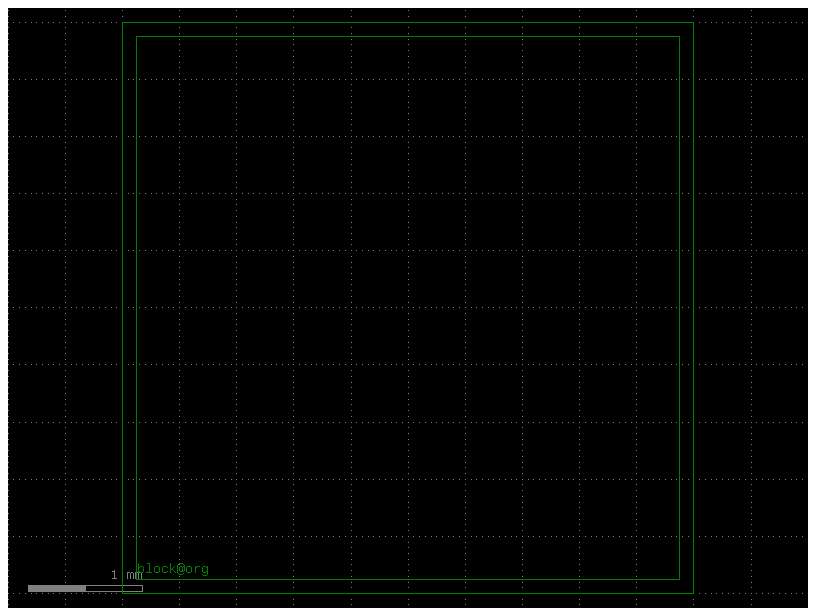

In [153]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

box.draw_ports()
box.show()
box.plot()

### Mantra: 
Once that we have a working 'new' component, we shall convert it into a Cell. This will allow us to have a hierarchical design

2026-06-12 15:59:20.449 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


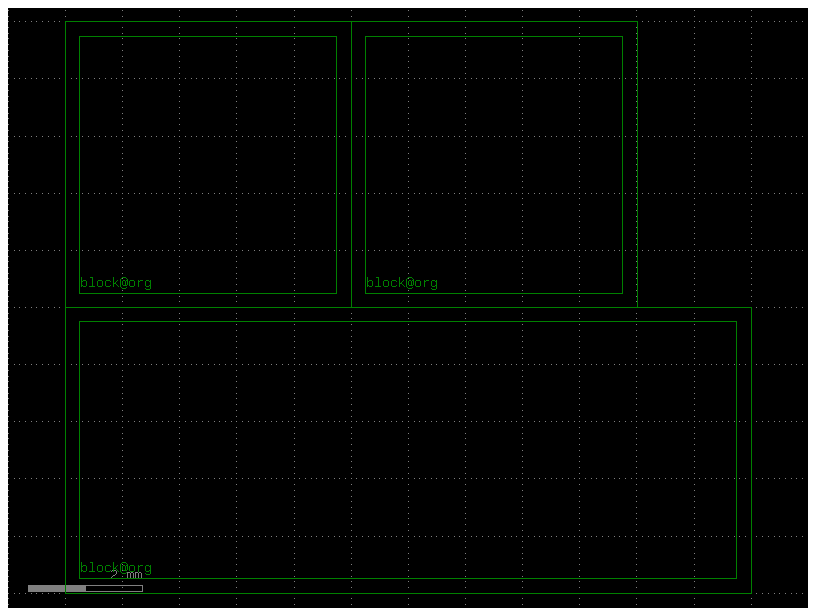

In [154]:
# 1. We define the cell as a function with it's corresponding parameters (and defaults)
gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
wafer = gf.Component()
dieW1 = 5000
dieW2 = 10000

c1 = wafer.add_ref(die(dieW = dieW))
c2 = wafer.add_ref(die(dieW = dieW))
c3 = wafer.add_ref(die(dieW = 12000))

c2.dmovex(dieW1)
c3.dmovey(-5000)
wafer.show()
wafer.plot()


## 3. Complete Layout

2026-06-12 15:59:21.086 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


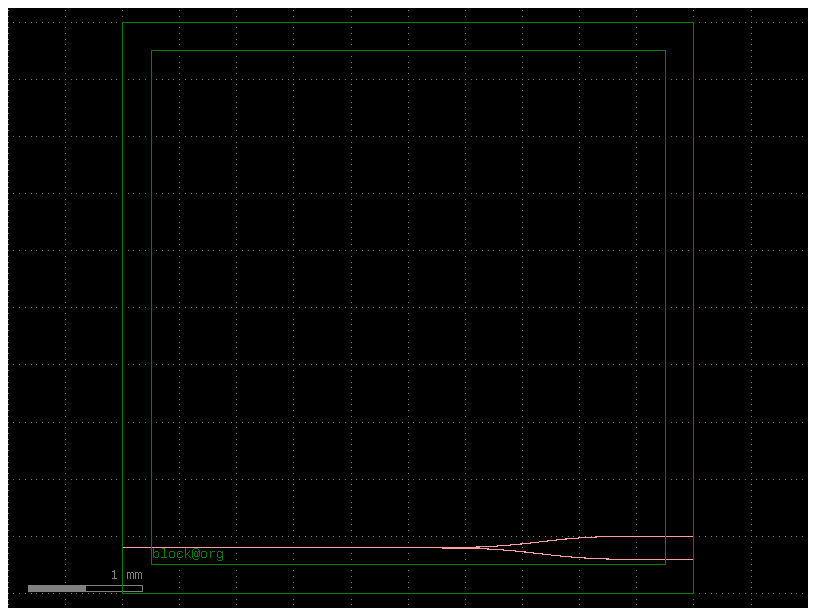

In [155]:
layer_wg  = "WG"
minrad = 50
dieW = 5000

main = gf.Component()

die_ref = main.add_ref(die(dieW = dieW, layer_box="FLOORPLAN"))

## Add first a test MMI routed from side to side
c_mmi = cells.mmi1x2()
mmi = main.add_ref(c_mmi)
mmi.dmovex(die_ref["block@org"].dx + 0.5*dieW).dmovey(die_ref['block@org'].dy + 150)

## Route waveguides from MMI to the die edges
xs = 'strip'
### First add the i/o waveguides - to be sure you 'cut' on a straight section
strin = (main.add_ref(gf.components.straight(length=500, cross_section='strip')).dmovex(0).dmovey(mmi['o1'].dy))
strout1 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o3'].dy-100).dmovex(dieW))
strout2 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o2'].dy+100).dmovex(dieW))
### Then route from the i/o waveguides to the MMI
gf.routing.route_single_sbend(main,port1=strin['o2'], port2=mmi['o1'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o2'], port2=strout2['o2'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o3'], port2=strout1['o2'], cross_section=xs)

main.plot()
main.show()

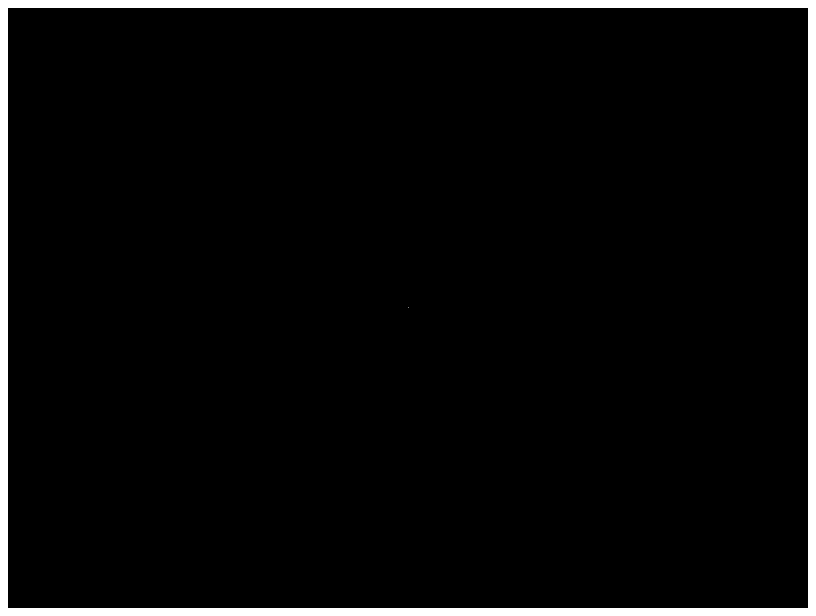

In [156]:
# Let's create a MMI tree

c = gf.Component()
c_mmi = cells.mmi1x2()
...
c.plot()

In [157]:
# Once we "test" the high-level component, we can create a cell for it
@gf.cell 
def mmi_tree_1x4(pad_x = 250 ,pad_y = 250):
    c = gf.Component()
    c_mmi = cells.mmi1x2()
    mmi1 = c.add_ref(c_mmi)
    mmi2 = c.add_ref(c_mmi)
    mmi3 = c.add_ref(c_mmi)

    mmi2.dmovex(pad_x).dmovey(pad_y)
    mmi3.dmovex(pad_x).dmovey(-pad_y)

    gf.routing.route_single_sbend(component=c, port1= mmi1['o2'], port2=mmi2['o1'],cross_section='strip')
    gf.routing.route_single_sbend(component=c, port1= mmi1['o3'], port2=mmi3['o1'],cross_section='strip')
    c.add_port(name='o1', port=mmi1['o1'])
    c.add_port(name='o2', port=mmi2['o2'])
    c.add_port(name='o3', port=mmi2['o3'])
    c.add_port(name='o4', port=mmi3['o2'])
    c.add_port(name='o5', port=mmi3['o3'])
    c.draw_ports()
    return c

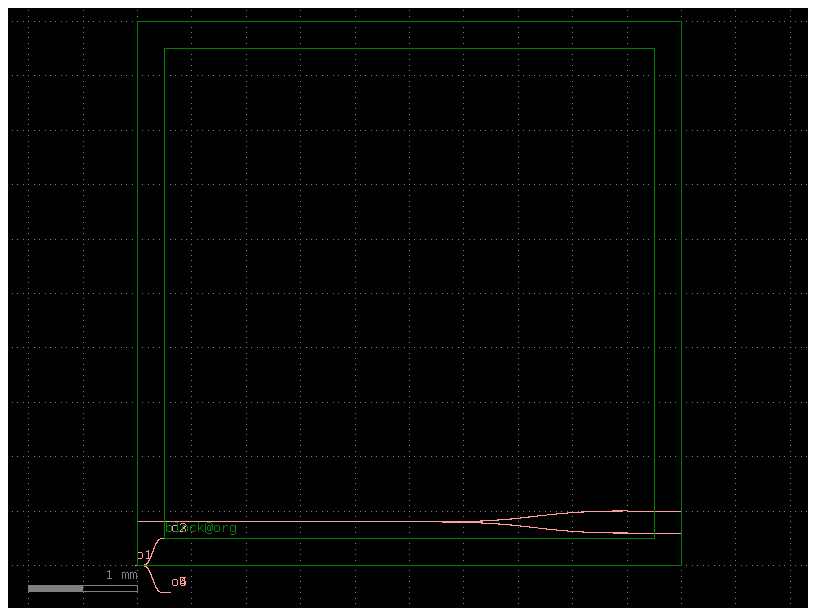

In [158]:
# With the cell created, we can instantiate and use it in our main component

cell_1x4 = main.add_ref(mmi_tree_1x4())
main.plot()


2026-06-12 15:59:21.992 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


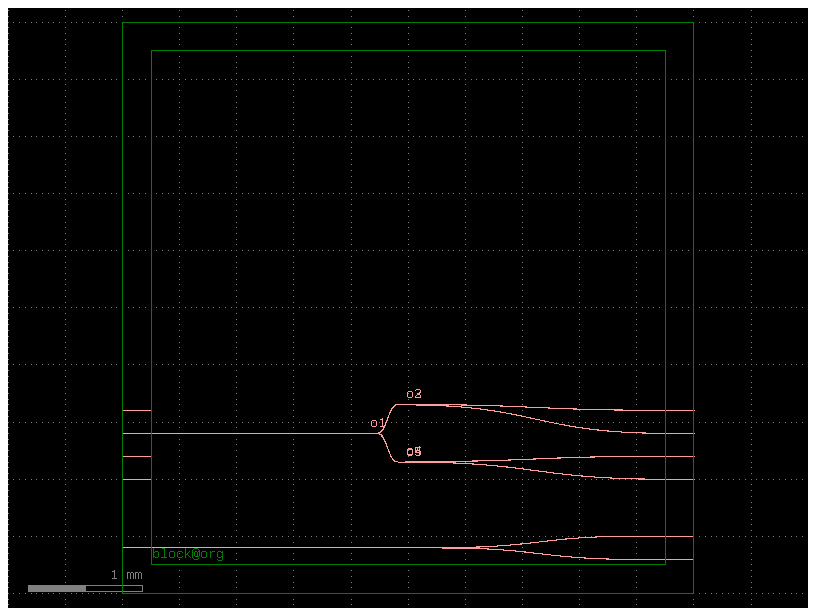

In [159]:
## Arrayed waveguides and MMI tree

sp = 200
border = 250

in_arr = main.add_ref(
    gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
).dmovey(
    1000
)  #!!!!!! Easy to put IO Waveguides for a complete design !!!!

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(1000)
)

cell_1x4.dmovex(0.5*dieW - mmi_tree_1x4().dxsize).dmovey(in_arr['o6'].dy)
gf.routing.route_single_sbend(component=main, port1=in_arr['o6'], port2=cell_1x4['o1'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o2'], port2=out_arr['o4'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o3'], port2=out_arr['o3'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o4'], port2=out_arr['o2'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o5'], port2=out_arr['o1'])
main.plot()
main.show()

### Mantra:
It's useful to use memorize this mantra: 
- Add_references 
- Connect_them
- Move_them

### Other Routing options examples:

Please check the GDSFactory Routing API for more information about advanced routing functionalities

[Routing API](https://gdsfactory.github.io/gdsfactory/api_routing.html) 

## 4. Exercises. 

Part a) Creating components
- Create a cell component for a unbalanced MZI, using 2x2 50:50 MMIs with arm length difference as parameter
- Create a cell component based on the previous, where the arms have thermal tuners on top of each one
- Create a cell component for an all-pass ring resonator, using 2x2 50:50 MMIs, with extra length parameter for different perimeters
- Create a cell component based on the previous, where the ring has a thermal tuner on top along all the perimeter
- Create a cell component based on existing GDSfactory spiral components, with length as parameter

Part b) Creating die
- Create a die  W = 5 mm x L = 10 mm 
- Create an array of I/Os spaced at 250 µm (as much I/Os as the width allows)
- Create a cell component of this die, with I/Os accessible to connect

Part c) Floorplaning and die layout
- Make an instance of the die as host component for your layout
- Add 3 sets of 3 straight waveguides, from left to right of the die, top, middle and bottom of the die
- Add 2 of each of the components above, with different lengths
- Connect all your components to the I/Os 

### LO1

##### LO1.a

2026-06-12 15:59:22.312 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


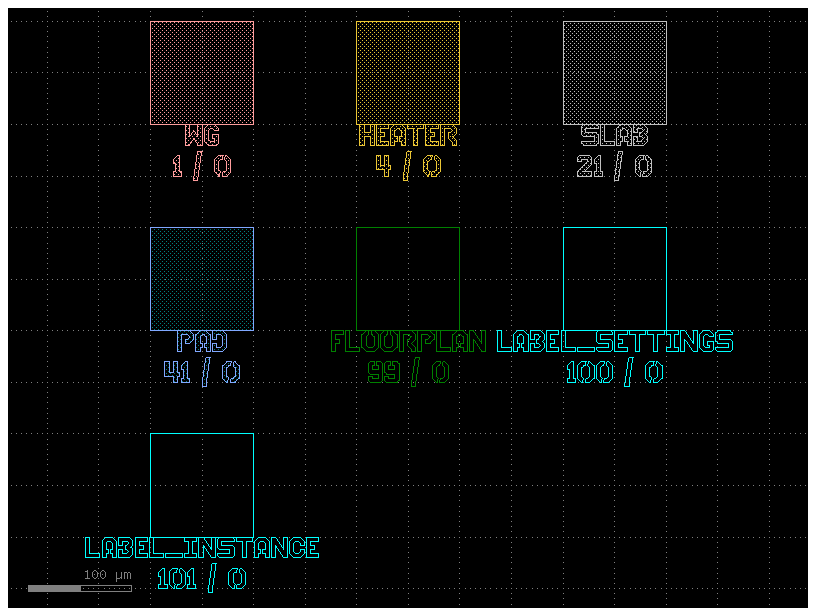

In [160]:
## Technology

# Let's view the layer distribution of this PDK
LAYER_VIEWS = PDK.layer_views
c = LAYER_VIEWS.preview_layerset()

c.show()
c.plot()

##### LO1.b

2026-06-12 15:59:22.695 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


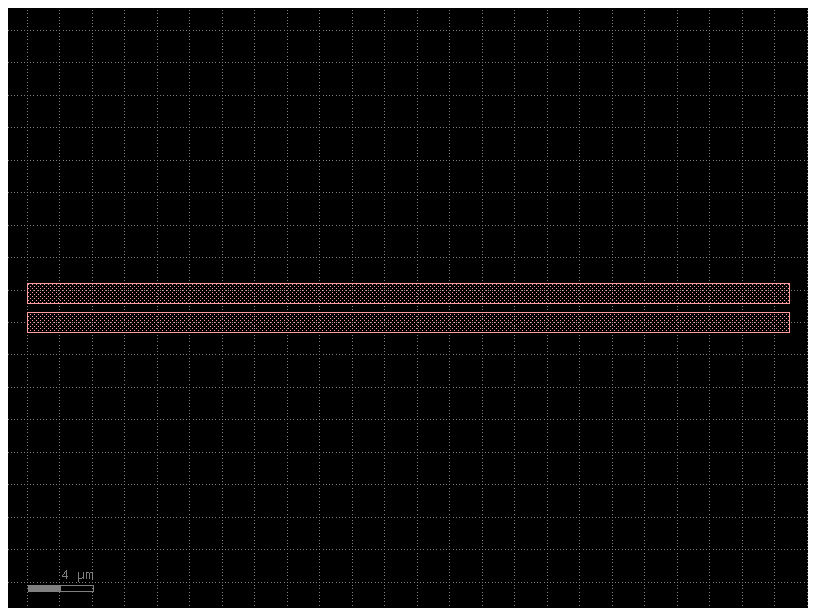

In [161]:
# Directional Coupler
L = 93.8 / 2
gap = 0.6
width = 1.2
separation = width + gap

xs = gf.cross_section.strip(width=width, layer="WG")
DC = gf.Component()
wg1 = DC.add_ref(
    gf.components.straight(
        length=L,
        cross_section=xs
    )
)
wg2 = DC.add_ref(
    gf.components.straight(
        length=L,
        cross_section=xs
    )
)
wg2.movey(separation)
DC.plot()
DC.show()

2026-06-12 15:59:23.001 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


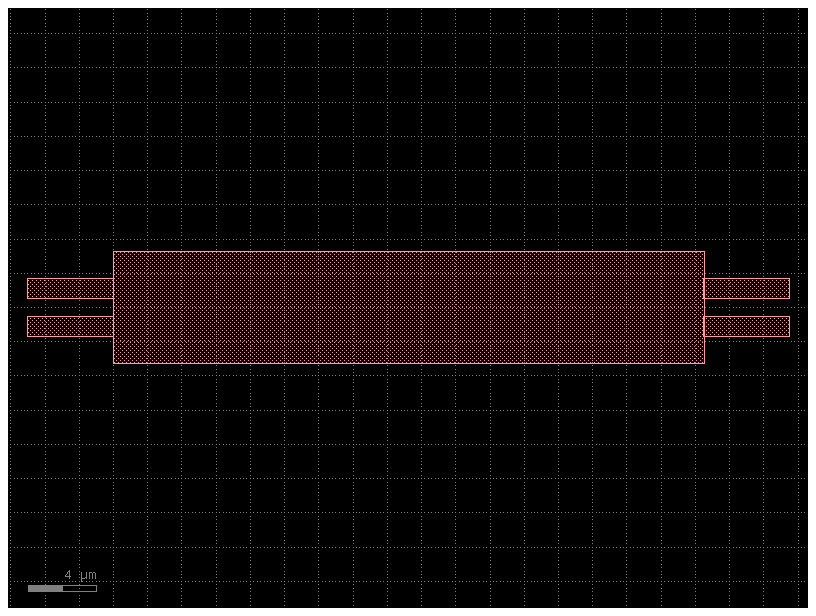

In [162]:
# 2x2 MMI
w_wg = 1.2          
w_mmi = 6.6         
l_mmi = 69.03598/2  
l_wg = 5.0          
gap_out = 1.5       

xs = gf.cross_section.strip(width=w_wg, layer="WG")
c = gf.Component()
mmi = c.add_ref(
    gf.components.rectangle(
        size=(l_mmi, w_mmi),
        layer="WG"
    )
)
# Centrar MMI en y = 0
mmi.dcenter = (l_mmi / 2, 0)
# Guías de entrada
wg1 = c.add_ref(
    gf.components.straight(
        length=l_wg,
        cross_section=xs
    )
).dmovex(-l_wg).dmovey(w_mmi/6)
wg2 = c.add_ref(
    gf.components.straight(
        length=l_wg,
        cross_section=xs
    )
).dmovex(-l_wg).dmovey(-w_mmi/6)
# Guías de salida
wg3 = c.add_ref(
    gf.components.straight(
        length=l_wg,
        cross_section=xs
    )
).dmovex(l_mmi).dmovey(w_mmi/6)
wg4 = c.add_ref(
    gf.components.straight(
        length=l_wg,
        cross_section=xs
    )
).dmovex(l_mmi).dmovey(-w_mmi/6)
c.plot()
c.show()

2026-06-12 15:59:23.276 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


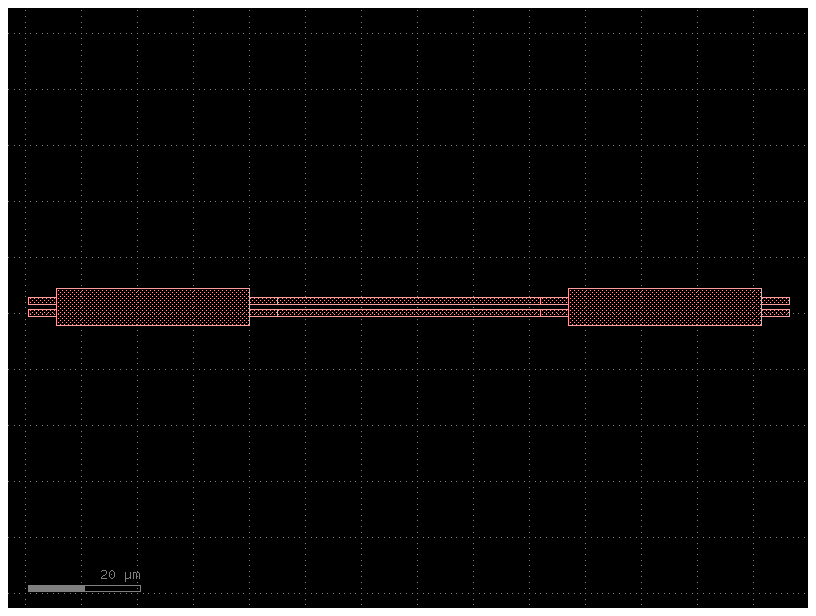

In [163]:
# Unbalanced MZI
w_wg = 1.2
w_mmi = 6.6
l_mmi = 69.03598 / 2
l_wg = 5.0
L = 93.8 / 2

xs = gf.cross_section.strip(width=w_wg, layer="WG")
# Crear el MMI como COMPONENTE
MMI_comp = gf.Component()

mmi_body = MMI_comp.add_ref(
    gf.components.rectangle(
        size=(l_mmi, w_mmi),
        layer="WG"
    )
)
mmi_body.dcenter = (l_mmi / 2, 0)
for y in [w_mmi/6, -w_mmi/6]:

    MMI_comp.add_ref(
        gf.components.straight(
            length=l_wg,
            cross_section=xs
        )
    ).dmovex(-l_wg).dmovey(y)

    MMI_comp.add_ref(
        gf.components.straight(
            length=l_wg,
            cross_section=xs
        )
    ).dmovex(l_mmi).dmovey(y)
# Crear MZI
MZI = gf.Component()
MMI_1 = MZI.add_ref(MMI_comp)
MMI_1.dmovex(-l_mmi)
MMI_1.dmovey(w_mmi / 6)
MMI_2 = MZI.add_ref(MMI_comp)
MMI_2.dmovex(2*l_wg + L)
MMI_2.dmovey(w_mmi / 6)

arm_top = MZI.add_ref(
    gf.components.straight(
        length=L,
        cross_section=xs
    )
)
arm_top.dmovex(l_wg)
arm_top.dmovey(2*w_mmi/6)
arm_bot = MZI.add_ref(
    gf.components.straight(
        length=L,
        cross_section=xs
    )
)
arm_bot.dmovex(l_wg)
arm_bot.dmovey(0)
MZI.plot()
MZI.show()

2026-06-12 15:59:23.551 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


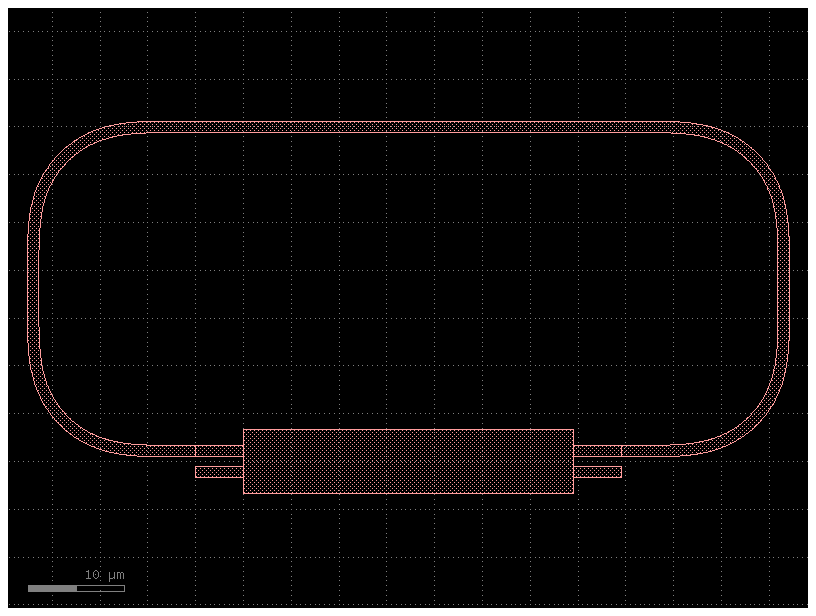

In [164]:
# Ring Resonator
w_wg = 1.2
w_mmi = 6.6
l_mmi = 69.03598 / 2
l_wg = 5.0

xs = gf.cross_section.strip(width=w_wg, layer="WG")
RR = gf.Component()
# MMI centrado en y = 0
mmi_body = RR.add_ref(
    gf.components.rectangle(
        size=(l_mmi, w_mmi),
        layer="WG"
    )
)
mmi_body.dmovey(-w_mmi/2)

y_sup = w_mmi / 6
y_inf = -w_mmi / 6

# Guías de acceso del MMI
for y in [y_sup, y_inf]:
    RR.add_ref(
        gf.components.straight(length=l_wg, cross_section=xs)
    ).dmovex(-l_wg).dmovey(y)

    RR.add_ref(
        gf.components.straight(length=l_wg, cross_section=xs)
    ).dmovex(l_mmi).dmovey(y)

x_left = -22
x_right = l_mmi + 22
y_top = 35

points = [
    (-l_wg, y_sup),
    (x_left, y_sup),
    (x_left, y_top),
    (x_right, y_top),
    (x_right, y_sup),
    (l_mmi + l_wg, y_sup),
]

ring_path = gf.path.smooth(
    points=points,
    radius=10
)

ring = gf.path.extrude(
    ring_path,
    cross_section=xs
)

RR.add_ref(ring)

RR.plot()
RR.show()

### LO2

#### LO2.a

2026-06-12 15:59:23.834 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


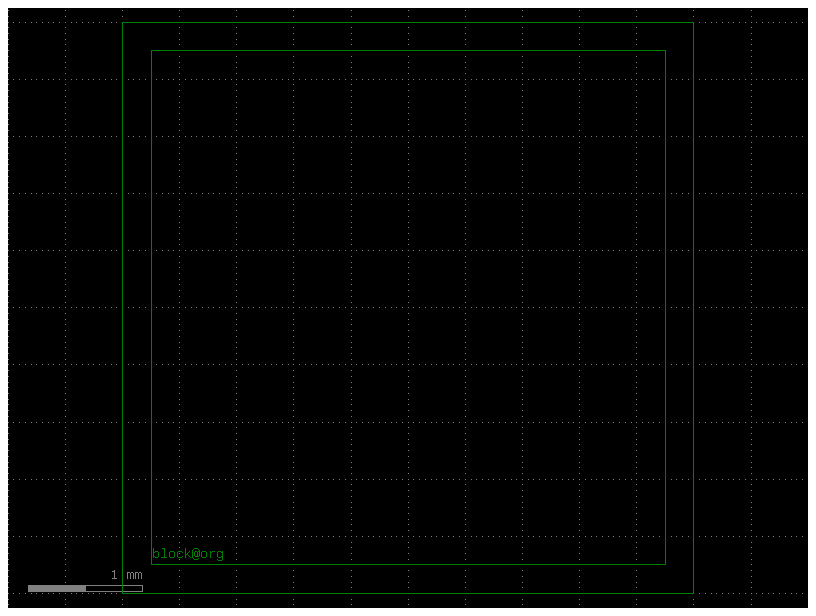

In [165]:
gf.clear_cache()

@gf.cell
def die(dieL=5000, dieW=5000, border=250, layer_box="FLOORPLAN"):

    box = gf.Component()

    obox = box.add_ref(
        gf.components.rectangle(
            size=(dieW, dieL),
            layer=layer_box
        )
    )

    ibox = box.add_ref(
        gf.components.rectangle(
            size=(dieW-border*2, dieL-border*2),
            layer=layer_box
        )
    ).dmovex(border).dmovey(border)

    box = gf.boolean(
        A=obox,
        B=ibox,
        operation="A-B",
        layer=layer_box
    )

    box.add_port(
        name="block@org",
        center=[border, border],
        width=1,
        orientation=0,
        layer=layer_box
    )

    box.draw_ports()

    return box

die().plot()
die().show()

2026-06-12 15:59:24.073 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


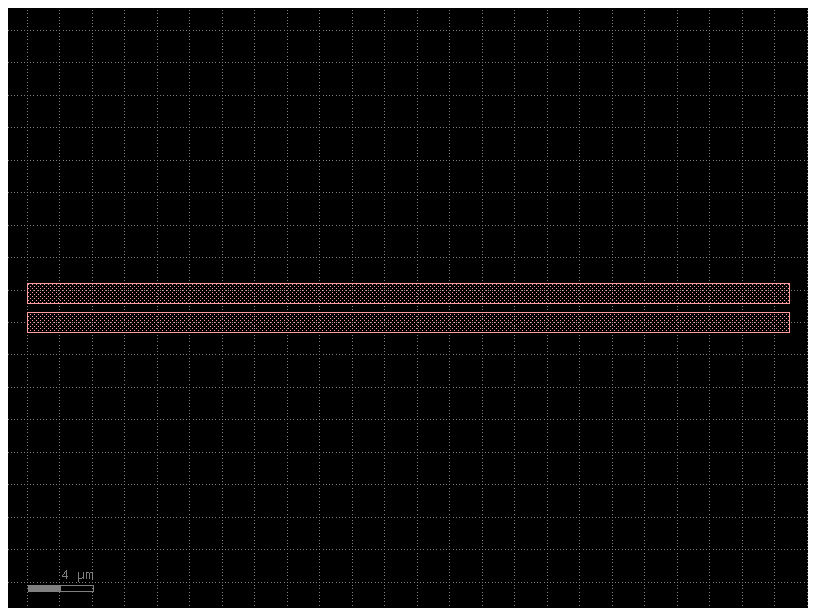

In [166]:
# Directional Coupler (como cell)
gf.clear_cache()
@gf.cell
def directional_coupler(
    L=93.8/2,
    gap=0.6,
    width=1.2,
    layer="WG"
):
    DC = gf.Component()
    separation = width + gap
    xs = gf.cross_section.strip(
        width=width,
        layer=layer
    )
    wg1 = DC.add_ref(
        gf.components.straight(
            length=L,
            cross_section=xs
        )
    )
    wg2 = DC.add_ref(
        gf.components.straight(
            length=L,
            cross_section=xs
        )
    )
    wg2.movey(separation)
    return DC
directional_coupler().plot()
directional_coupler().show()

2026-06-12 15:59:24.312 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


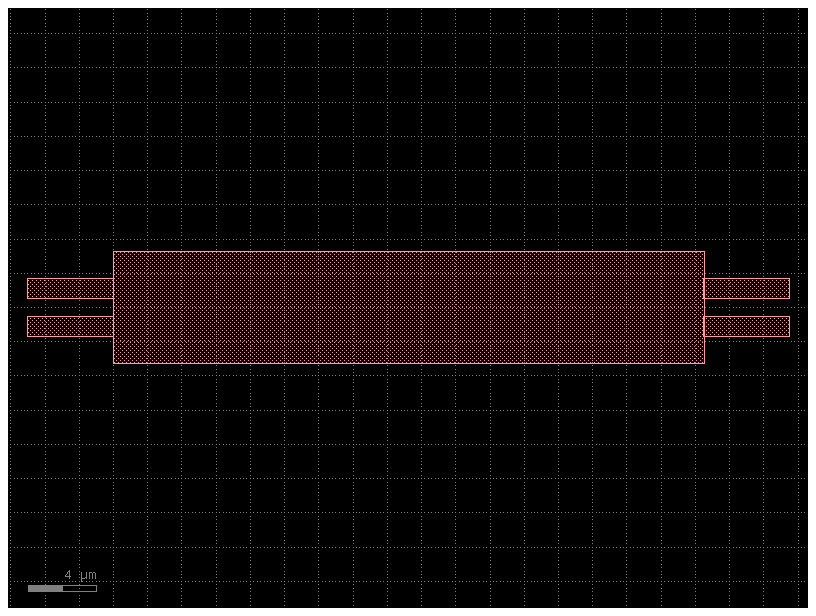

In [167]:
# 2x2 MMI (como cell)
gf.clear_cache()
@gf.cell
def mmi_2x2(
    w_wg=1.2,
    w_mmi=6.6,
    l_mmi=69.03598/2,
    l_wg=5.0,
    layer="WG"
):
    c = gf.Component()
    xs = gf.cross_section.strip(
        width=w_wg,
        layer=layer
    )
    mmi = c.add_ref(
        gf.components.rectangle(
            size=(l_mmi, w_mmi),
            layer=layer
        )
    )
    # Centrar MMI en y = 0
    mmi.dcenter = (l_mmi / 2, 0)
    # Guías de entrada
    c.add_ref(
        gf.components.straight(
            length=l_wg,
            cross_section=xs
        )
    ).dmovex(-l_wg).dmovey(w_mmi/6)
    c.add_ref(
        gf.components.straight(
            length=l_wg,
            cross_section=xs
        )
    ).dmovex(-l_wg).dmovey(-w_mmi/6)
    # Guías de salida
    c.add_ref(
        gf.components.straight(
            length=l_wg,
            cross_section=xs
        )
    ).dmovex(l_mmi).dmovey(w_mmi/6)
    c.add_ref(
        gf.components.straight(
            length=l_wg,
            cross_section=xs
        )
    ).dmovex(l_mmi).dmovey(-w_mmi/6)
    return c
mmi_2x2().plot()
mmi_2x2().show()

2026-06-12 15:59:24.821 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


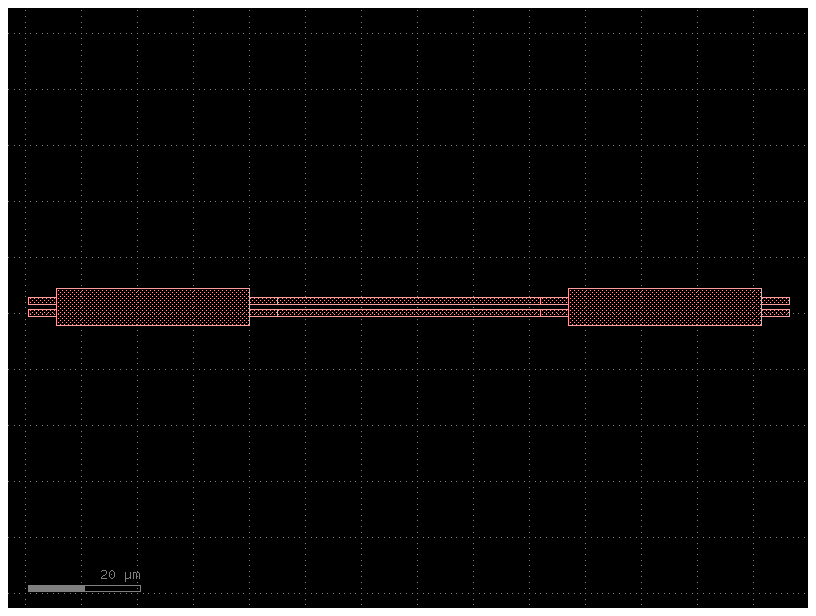

In [168]:
# MZI (como cell)
gf.clear_cache()
@gf.cell
def mzi_unbalanced_cell(
    w_wg=1.2,
    w_mmi=6.6,
    l_mmi=69.03598/2,
    l_wg=5.0,
    L=93.8/2,
    layer="WG"
):
    xs = gf.cross_section.strip(width=w_wg, layer=layer)
    # MMI component
    MMI_comp = gf.Component()
    mmi_body = MMI_comp.add_ref(
        gf.components.rectangle(
            size=(l_mmi, w_mmi),
            layer=layer
        )
    )
    mmi_body.dcenter = (l_mmi / 2, 0)
    for y in [w_mmi/6, -w_mmi/6]:
        MMI_comp.add_ref(
            gf.components.straight(
                length=l_wg,
                cross_section=xs
            )
        ).dmovex(-l_wg).dmovey(y)
        MMI_comp.add_ref(
            gf.components.straight(
                length=l_wg,
                cross_section=xs
            )
        ).dmovex(l_mmi).dmovey(y)
    # MZI component
    MZI = gf.Component()
    MMI_1 = MZI.add_ref(MMI_comp)
    MMI_1.dmovex(-l_mmi)
    MMI_1.dmovey(w_mmi / 6)
    MMI_2 = MZI.add_ref(MMI_comp)
    MMI_2.dmovex(2*l_wg + L)
    MMI_2.dmovey(w_mmi / 6)
    arm_top = MZI.add_ref(
        gf.components.straight(
            length=L,
            cross_section=xs
        )
    )
    arm_top.dmovex(l_wg)
    arm_top.dmovey(2*w_mmi/6)
    arm_bot = MZI.add_ref(
        gf.components.straight(
            length=L,
            cross_section=xs
        )
    )
    arm_bot.dmovex(l_wg)
    arm_bot.dmovey(0)
    return MZI
mzi_unbalanced_cell().plot()
mzi_unbalanced_cell().show()

2026-06-12 15:59:25.191 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


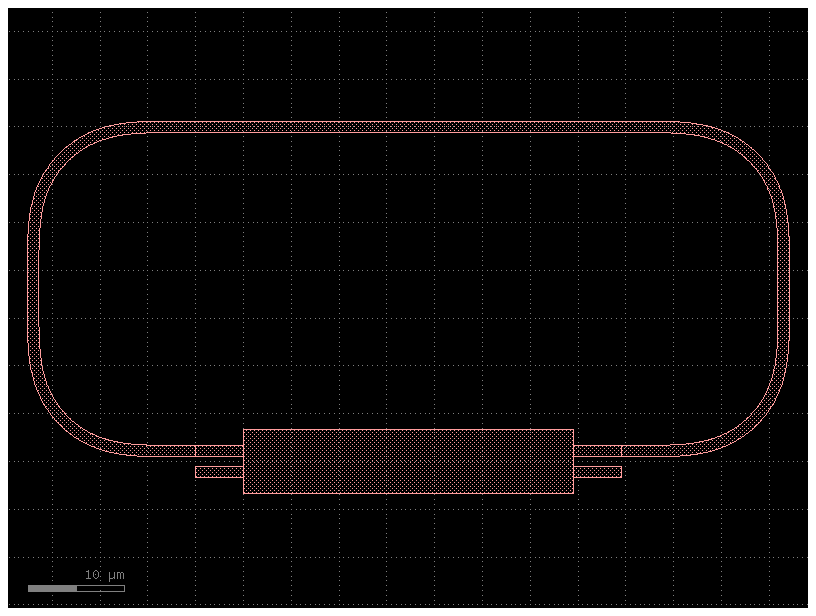

In [169]:
# Ring Resonator (como cell)
@gf.cell
def ring_resonator_cell(
    w_wg=1.2,
    w_mmi=6.6,
    l_mmi=69.03598/2,
    l_wg=5.0,
    radius_ring=10,
    layer="WG"
):
    xs = gf.cross_section.strip(
        width=w_wg,
        layer=layer
    )
    RR = gf.Component()
    # Región MMI
    mmi_body = RR.add_ref(
        gf.components.rectangle(
            size=(l_mmi, w_mmi),
            layer=layer
        )
    )
    mmi_body.dmovey(-w_mmi/2)
    y_sup = w_mmi/6
    y_inf = -w_mmi/6
    
    for y in [y_sup, y_inf]:

        RR.add_ref(
            gf.components.straight(
                length=l_wg,
                cross_section=xs
            )
        ).dmovex(-l_wg).dmovey(y)

        RR.add_ref(
            gf.components.straight(
                length=l_wg,
                cross_section=xs
            )
        ).dmovex(l_mmi).dmovey(y)

    x_left = -22
    x_right = l_mmi + 22
    y_top = 35

    ring_points = [
        (-l_wg, y_sup),
        (x_left, y_sup),
        (x_left, y_top),
        (x_right, y_top),
        (x_right, y_sup),
        (l_mmi + l_wg, y_sup),
    ]
    ring_path = gf.path.smooth(
        points=ring_points,
        radius=radius_ring
    )
    ring = gf.path.extrude(
        ring_path,
        cross_section=xs
    )

    RR.add_ref(ring)
    return RR
ring_resonator_cell().plot()
ring_resonator_cell().show()

### LO3

2026-06-12 15:59:25.586 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-12 15:59:25.783 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


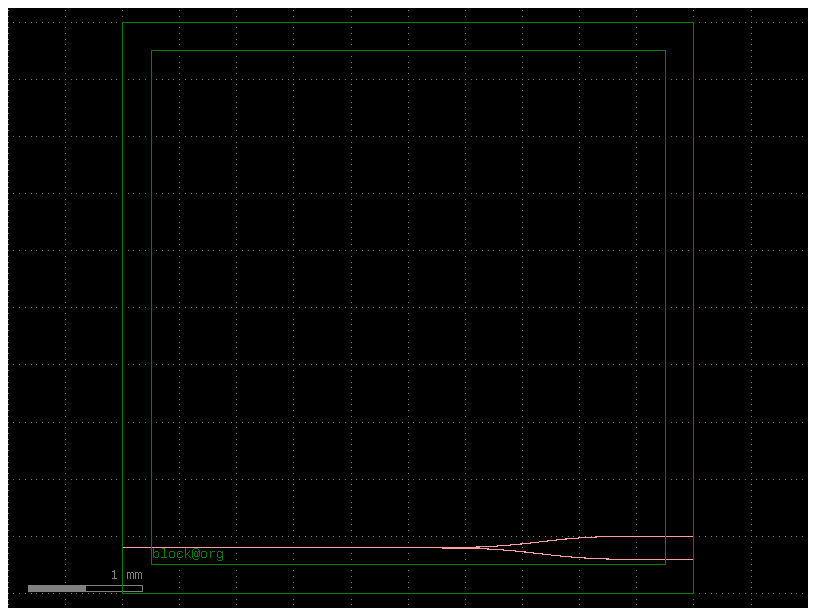

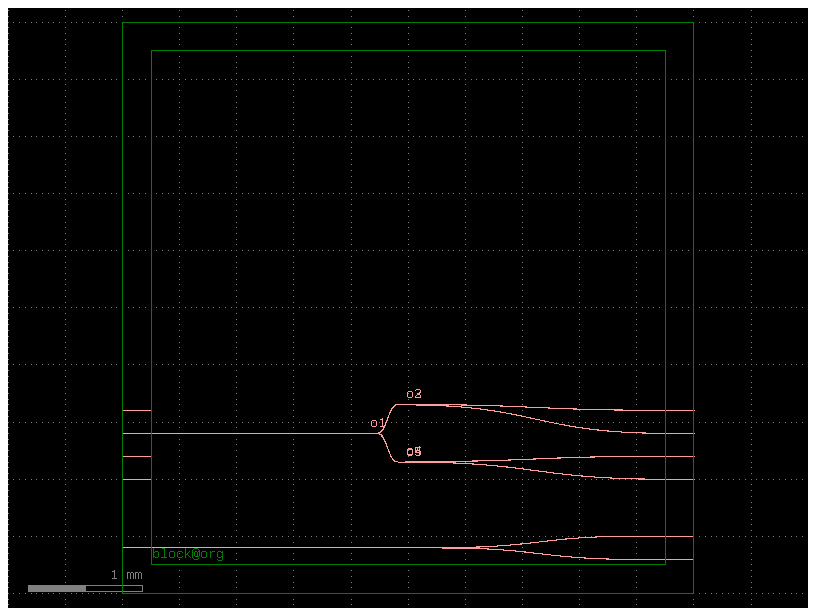

In [170]:
gf.clear_cache()

layer_wg = "WG"
minrad = 50
dieW = 5000
xs = "strip"

main = gf.Component()

die_ref = main.add_ref(
    die(
        dieW=dieW,
        layer_box="FLOORPLAN"
    )
)

# Bloque 1: MMI 1x2 dentro del die
c_mmi = cells.mmi1x2()
mmi = main.add_ref(c_mmi)

mmi.dmovex(
    die_ref["block@org"].dx + 0.5*dieW
).dmovey(
    die_ref["block@org"].dy + 150
)

strin = (
    main.add_ref(
        gf.components.straight(
            length=500,
            cross_section=xs
        )
    )
    .dmovex(0)
    .dmovey(mmi["o1"].dy)
)

strout1 = (
    main.add_ref(
        gf.components.straight(
            length=500,
            cross_section=xs
        )
    )
    .drotate(180)
    .dmovey(mmi.ports["o3"].dy - 100)
    .dmovex(dieW)
)

strout2 = (
    main.add_ref(
        gf.components.straight(
            length=500,
            cross_section=xs
        )
    )
    .drotate(180)
    .dmovey(mmi.ports["o2"].dy + 100)
    .dmovex(dieW)
)

gf.routing.route_single_sbend(
    main,
    port1=strin["o2"],
    port2=mmi["o1"],
    cross_section=xs
)

gf.routing.route_single_sbend(
    main,
    port1=mmi["o2"],
    port2=strout2["o2"],
    cross_section=xs
)

gf.routing.route_single_sbend(
    main,
    port1=mmi["o3"],
    port2=strout1["o2"],
    cross_section=xs
)

main.plot()
main.show()


# Bloque 2 y 3: MMI tree 1x4 como cell
@gf.cell
def mmi_tree_1x4(pad_x=250, pad_y=250):

    c = gf.Component()
    c_mmi = cells.mmi1x2()

    mmi1 = c.add_ref(c_mmi)
    mmi2 = c.add_ref(c_mmi)
    mmi3 = c.add_ref(c_mmi)

    mmi2.dmovex(pad_x).dmovey(pad_y)
    mmi3.dmovex(pad_x).dmovey(-pad_y)

    gf.routing.route_single_sbend(
        component=c,
        port1=mmi1["o2"],
        port2=mmi2["o1"],
        cross_section="strip"
    )

    gf.routing.route_single_sbend(
        component=c,
        port1=mmi1["o3"],
        port2=mmi3["o1"],
        cross_section="strip"
    )

    c.add_port(name="o1", port=mmi1["o1"])
    c.add_port(name="o2", port=mmi2["o2"])
    c.add_port(name="o3", port=mmi2["o3"])
    c.add_port(name="o4", port=mmi3["o2"])
    c.add_port(name="o5", port=mmi3["o3"])

    c.draw_ports()

    return c


cell_1x4 = main.add_ref(
    mmi_tree_1x4()
)

# Bloque 4: Arrays I/O + conexiones
sp = 200
border = 250

in_arr = main.add_ref(
    gf.components.straight_array(
        n=4,
        spacing=sp,
        length=border,
        cross_section=xs
    )
).dmovey(1000)

out_arr = (
    main.add_ref(
        gf.components.straight_array(
            n=4,
            spacing=sp,
            length=border,
            cross_section=xs
        )
    )
    .dmovex(dieW - border)
    .dmovey(1000)
)

cell_1x4.dmovex(
    0.5*dieW - mmi_tree_1x4().dxsize
).dmovey(
    in_arr["o6"].dy
)

gf.routing.route_single_sbend(
    component=main,
    port1=in_arr["o6"],
    port2=cell_1x4["o1"],
    cross_section=xs
)

gf.routing.route_single_sbend(
    component=main,
    port1=cell_1x4["o2"],
    port2=out_arr["o4"],
    cross_section=xs
)

gf.routing.route_single_sbend(
    component=main,
    port1=cell_1x4["o3"],
    port2=out_arr["o3"],
    cross_section=xs
)

gf.routing.route_single_sbend(
    component=main,
    port1=cell_1x4["o4"],
    port2=out_arr["o2"],
    cross_section=xs
)

gf.routing.route_single_sbend(
    component=main,
    port1=cell_1x4["o5"],
    port2=out_arr["o1"],
    cross_section=xs
)

main.plot()
main.show()

### LO4

In [171]:
gf.clear_cache()

xs = gf.cross_section.strip(width=1.2, layer="WG")
heater_layer = (47, 0)

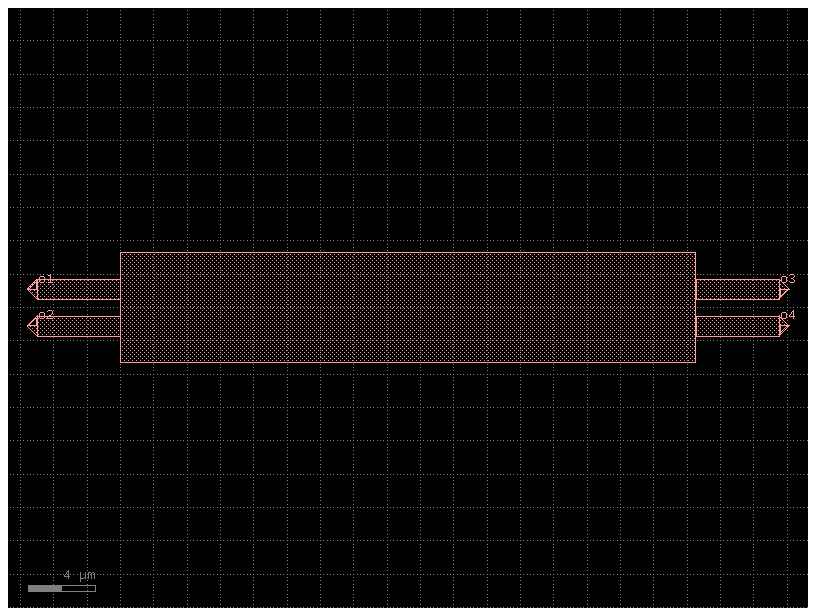

In [172]:
@gf.cell
def mmi_2x2_50_50(
    w_wg=1.2,
    w_mmi=6.6,
    l_mmi=69.03598/2,
    l_wg=5.0,
):
    c = gf.Component()

    xs = gf.cross_section.strip(width=w_wg, layer="WG")

    body = c.add_ref(
        gf.components.rectangle(
            size=(l_mmi, w_mmi),
            layer="WG"
        )
    )
    body.dcenter = (l_mmi/2, 0)

    y_top = w_mmi/6
    y_bot = -w_mmi/6

    for y in [y_top, y_bot]:
        c.add_ref(
            gf.components.straight(length=l_wg, cross_section=xs)
        ).dmovex(-l_wg).dmovey(y)

        c.add_ref(
            gf.components.straight(length=l_wg, cross_section=xs)
        ).dmovex(l_mmi).dmovey(y)

    c.add_port("o1", center=(-l_wg, y_top), width=w_wg, orientation=180, layer="WG")
    c.add_port("o2", center=(-l_wg, y_bot), width=w_wg, orientation=180, layer="WG")
    c.add_port("o3", center=(l_mmi+l_wg, y_top), width=w_wg, orientation=0, layer="WG")
    c.add_port("o4", center=(l_mmi+l_wg, y_bot), width=w_wg, orientation=0, layer="WG")

    c.draw_ports()
    return c


mmi_2x2_50_50().plot()

#### Parte a)

2026-06-12 15:59:26.480 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


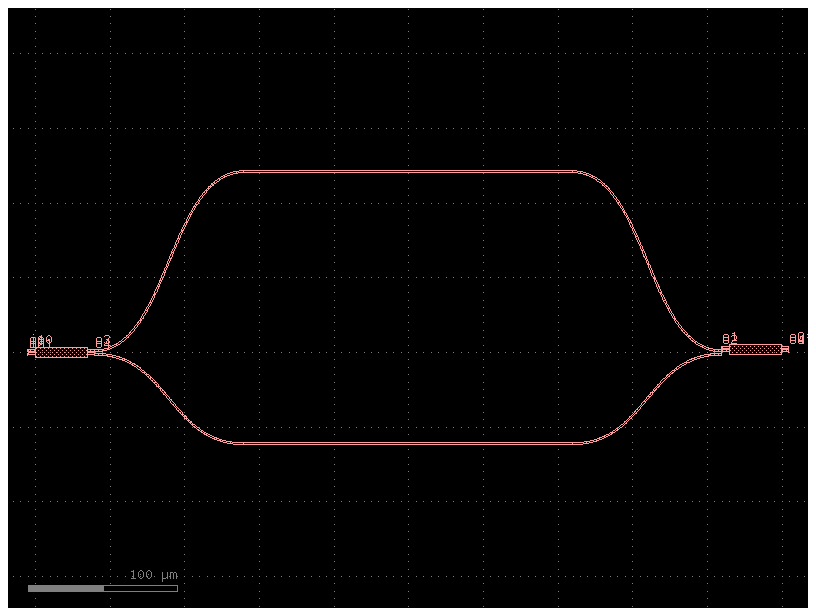

In [173]:
## a.1
@gf.cell
def mzi_desbalanceado(delta_l=120, arm_length=220, sbend_length=100, arm_offset=60):
    c = gf.Component()

    xs = gf.cross_section.strip(width=1.2, layer="WG")

    mmi_in = c.add_ref(mmi_2x2_50_50())
    mmi_out = c.add_ref(mmi_2x2_50_50())

    delta_half = delta_l / 2
    top_offset = arm_offset + delta_half
    bot_offset = arm_offset

    top_in = c.add_ref(
        gf.components.bend_s(size=(sbend_length, top_offset), cross_section=xs)
    )
    top_in.connect("o1", mmi_in["o3"])

    top_arm = c.add_ref(
        gf.components.straight(length=arm_length, cross_section=xs)
    )
    top_arm.connect("o1", top_in["o2"])

    top_out = c.add_ref(
        gf.components.bend_s(size=(sbend_length, -top_offset), cross_section=xs)
    )
    top_out.connect("o1", top_arm["o2"])

    bot_in = c.add_ref(
        gf.components.bend_s(size=(sbend_length, -bot_offset), cross_section=xs)
    )
    bot_in.connect("o1", mmi_in["o4"])

    bot_arm = c.add_ref(
        gf.components.straight(length=arm_length, cross_section=xs)
    )
    bot_arm.connect("o1", bot_in["o2"])

    bot_out = c.add_ref(
        gf.components.bend_s(size=(sbend_length, bot_offset), cross_section=xs)
    )
    bot_out.connect("o1", bot_arm["o2"])

    mmi_out.connect("o2", top_out["o2"])

    c.add_port("in0", port=mmi_in["o1"])
    c.add_port("in1", port=mmi_in["o2"])
    c.add_port("out0", port=mmi_out["o4"])
    c.add_port("out1", port=mmi_out["o3"])

    c.draw_ports()
    return c


mzi_desbalanceado(delta_l=120).plot()
mzi_desbalanceado(delta_l=120).show()

2026-06-12 15:59:26.857 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


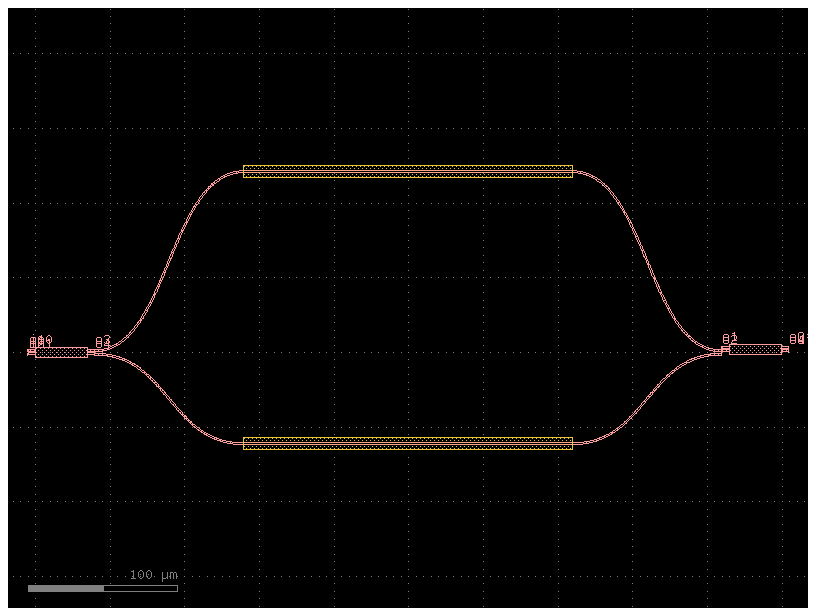

In [174]:
## a.2
gf.clear_cache()
@gf.cell
def mzi_desbalanceado_heater(delta_l=120, arm_length=220, sbend_length=100, arm_offset=60):
    c = gf.Component()

    xs = gf.cross_section.strip(width=1.2, layer="WG")
    heater_layer = "HEATER"   

    mmi_in = c.add_ref(mmi_2x2_50_50())
    mmi_out = c.add_ref(mmi_2x2_50_50())

    delta_half = delta_l / 2
    top_offset = arm_offset + delta_half
    bot_offset = arm_offset

    # Brazo superior
    top_in = c.add_ref(
        gf.components.bend_s(size=(sbend_length, top_offset), cross_section=xs)
    )
    top_in.connect("o1", mmi_in["o3"])

    top_arm = c.add_ref(
        gf.components.straight(length=arm_length, cross_section=xs)
    )
    top_arm.connect("o1", top_in["o2"])

    top_out = c.add_ref(
        gf.components.bend_s(size=(sbend_length, -top_offset), cross_section=xs)
    )
    top_out.connect("o1", top_arm["o2"])

    # Brazo inferior
    bot_in = c.add_ref(
        gf.components.bend_s(size=(sbend_length, -bot_offset), cross_section=xs)
    )
    bot_in.connect("o1", mmi_in["o4"])

    bot_arm = c.add_ref(
        gf.components.straight(length=arm_length, cross_section=xs)
    )
    bot_arm.connect("o1", bot_in["o2"])

    bot_out = c.add_ref(
        gf.components.bend_s(size=(sbend_length, bot_offset), cross_section=xs)
    )
    bot_out.connect("o1", bot_arm["o2"])

    # MMI de salida
    mmi_out.connect("o2", top_out["o2"])

    heater_w = 8

    top_y = top_arm["o1"].dy
    bot_y = bot_arm["o1"].dy

    top_x1 = top_arm["o1"].dx
    top_x2 = top_arm["o2"].dx
    bot_x1 = bot_arm["o1"].dx
    bot_x2 = bot_arm["o2"].dx

    heater_top = c.add_ref(
        gf.components.rectangle(
            size=(abs(top_x2 - top_x1), heater_w),
            layer=heater_layer
        )
    )
    heater_top.dmovex(min(top_x1, top_x2))
    heater_top.dmovey(top_y - heater_w/2)

    heater_bot = c.add_ref(
        gf.components.rectangle(
            size=(abs(bot_x2 - bot_x1), heater_w),
            layer=heater_layer
        )
    )
    heater_bot.dmovex(min(bot_x1, bot_x2))
    heater_bot.dmovey(bot_y - heater_w/2)

    c.add_port("in0", port=mmi_in["o1"])
    c.add_port("in1", port=mmi_in["o2"])
    c.add_port("out0", port=mmi_out["o4"])
    c.add_port("out1", port=mmi_out["o3"])

    c.draw_ports()
    return c


mzi_desbalanceado_heater(delta_l=120).plot()
mzi_desbalanceado_heater(delta_l=120).show()

2026-06-12 15:59:27.241 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


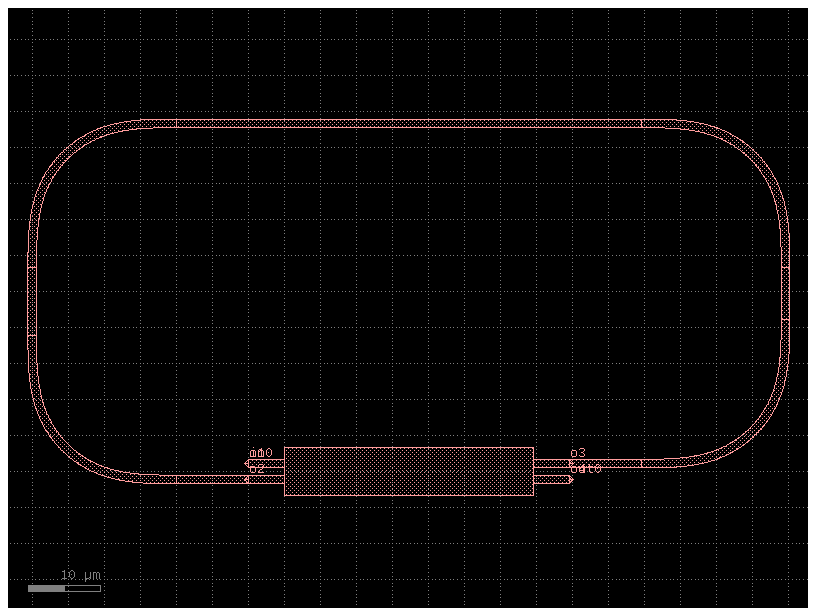

In [175]:
## a.3
gf.clear_cache()
@gf.cell
def ring_allpass_mmi(extra_length=20):
    c = gf.Component()

    xs = gf.cross_section.strip(width=1.2, layer="WG")

    mmi = c.add_ref(mmi_2x2_50_50())

    side_margin = 30
    base_height = 35
    bend_radius = 20

    x_right = mmi["o3"].center[0] + side_margin
    x_left = mmi["o2"].center[0] - side_margin
    y_bottom = mmi["o2"].center[1]
    y_top = mmi.ymax + base_height + extra_length/2

    gf.routing.route_single(
        component=c,
        port1=mmi["o3"],
        port2=mmi["o2"],
        steps=[
            {"x": x_right},
            {"y": y_top},
            {"x": x_left},
            {"y": y_bottom},
        ],
        radius=bend_radius,
        cross_section=xs,
    )

    c.add_port("in0", port=mmi["o1"])
    c.add_port("out0", port=mmi["o4"])

    c.draw_ports()
    return c


c3 = ring_allpass_mmi(extra_length=20)
c3.plot()
c3.show()

2026-06-12 15:59:27.594 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


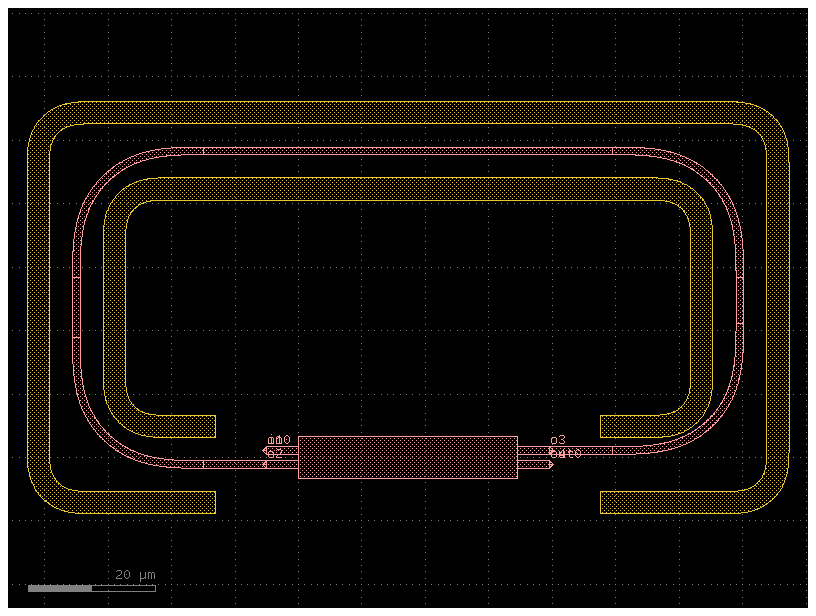

In [176]:
## a.4
gf.clear_cache()

@gf.cell
def ring_allpass_mmi_heater_v3(extra_length=20):
    c = gf.Component()

    xs = gf.cross_section.strip(width=1.2, layer="WG")
    heater_xs = gf.cross_section.strip(width=3.5, layer="HEATER")

    mmi = c.add_ref(mmi_2x2_50_50())

    side_margin = 30
    base_height = 35
    ring_radius = 20

    x_left = mmi["o2"].center[0] - side_margin
    x_right = mmi["o3"].center[0] + side_margin

    y_bottom = mmi["o2"].center[1]
    y_top = mmi.ymax + base_height + extra_length/2

    # Anillo óptico
    gf.routing.route_single(
        component=c,
        port1=mmi["o3"],
        port2=mmi["o2"],
        steps=[
            {"x": x_right},
            {"y": y_top},
            {"x": x_left},
            {"y": y_bottom},
        ],
        radius=ring_radius,
        cross_section=xs,
    )

    # Heater exterior
    outer_offset = 6
    inner_offset = 6
    foot = 22
    heater_radius = 6

    outer_points = [
        (x_left + foot, y_bottom - outer_offset),
        (x_left - outer_offset, y_bottom - outer_offset),
        (x_left - outer_offset, y_top + outer_offset),
        (x_right + outer_offset, y_top + outer_offset),
        (x_right + outer_offset, y_bottom - outer_offset),
        (x_right - foot, y_bottom - outer_offset),
    ]

    outer_path = gf.path.smooth(
        points=outer_points,
        radius=heater_radius
    )

    outer_heater = gf.path.extrude(
        outer_path,
        cross_section=heater_xs
    )

    c.add_ref(outer_heater)

    # Heater interior
    inner_points = [
        (x_left + foot, y_bottom + inner_offset),
        (x_left + inner_offset, y_bottom + inner_offset),
        (x_left + inner_offset, y_top - inner_offset),
        (x_right - inner_offset, y_top - inner_offset),
        (x_right - inner_offset, y_bottom + inner_offset),
        (x_right - foot, y_bottom + inner_offset),
    ]

    inner_path = gf.path.smooth(
        points=inner_points,
        radius=heater_radius
    )

    inner_heater = gf.path.extrude(
        inner_path,
        cross_section=heater_xs
    )

    c.add_ref(inner_heater)

    c.add_port("in0", port=mmi["o1"])
    c.add_port("out0", port=mmi["o4"])

    c.draw_ports()
    return c


c4 = ring_allpass_mmi_heater_v3(extra_length=20)
c4.plot()
c4.show()

2026-06-12 15:59:32.215 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


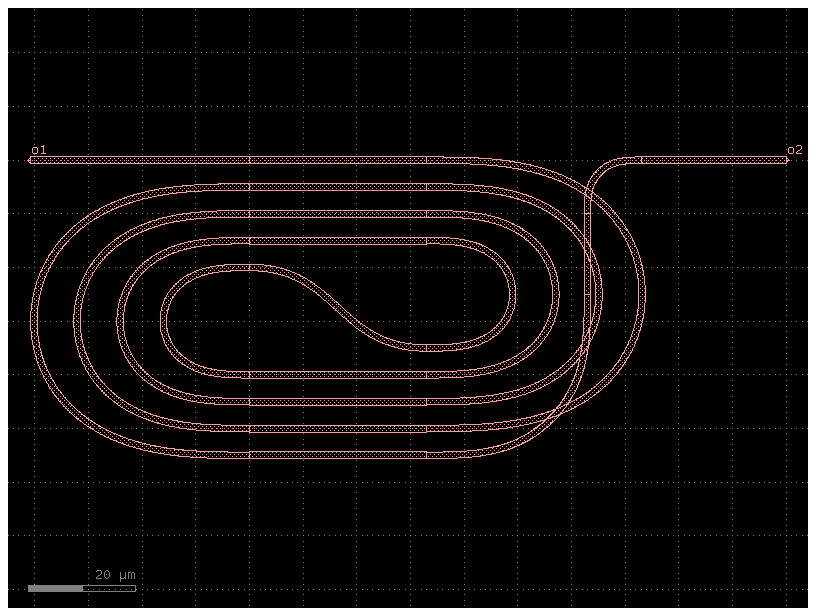

In [177]:
## a.5
gf.clear_cache()

@gf.cell
def spiral_length_cell(length=1000):
    c = gf.Component()

    xs = gf.cross_section.strip(
        width=1.2,
        layer="WG"
    )

    spiral = c.add_ref(
        gf.components.spiral_racetrack_fixed_length(
            length=length,
            in_out_port_spacing=100,
            bend="bend_euler",
            cross_section=xs
        )
    )

    c.add_ports(spiral.ports)
    c.draw_ports()

    c.info["length_um"] = length

    return c


c5 = spiral_length_cell(length=1000)

c5.draw_ports()
c5.plot()
c5.show()

#### Parte b)

2026-06-12 16:21:47.927 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


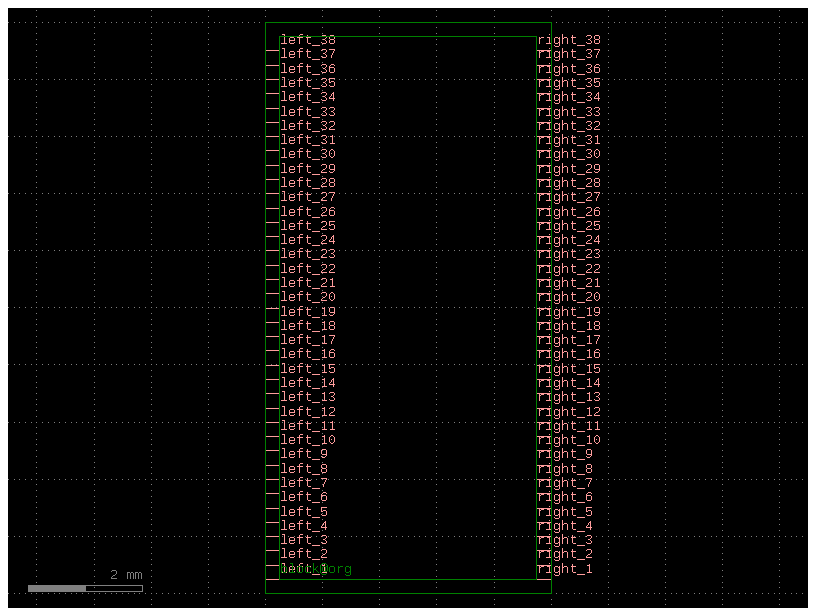

In [196]:
## Die W = 5 mm x L = 10 mm with I/Os every 250 um

gf.clear_cache()

@gf.cell
def die_with_ios(dieW=5000, dieL=10000, border=250, spacing=250, xs="strip"):

    c = gf.Component()

    # Die 5 mm x 10 mm
    die_ref = c.add_ref(
        die(
            dieW=dieW,
            dieL=dieL,
            border=border,
            layer_box="FLOORPLAN"
        )
    )

    # Número de I/Os que caben en la altura útil
    n_ios = int((dieL - 2 * border) / spacing)

    for i in range(n_ios):

        y = border + i * spacing

        # I/O izquierdo
        left_wg = c.add_ref(
            gf.components.straight(
                length=border,
                cross_section=xs
            )
        )
        left_wg.dmovex(0)
        left_wg.dmovey(y)

        # I/O derecho
        right_wg = c.add_ref(
            gf.components.straight(
                length=border,
                cross_section=xs
            )
        )
        right_wg.dmovex(dieW - border)
        right_wg.dmovey(y)

        # Puertos accesibles hacia el interior del chip
        c.add_port(
            name=f"left_{i+1}",
            port=left_wg["o2"]
        )

        c.add_port(
            name=f"right_{i+1}",
            port=right_wg["o1"]
        )

    c.draw_ports()

    return c


die_io = die_with_ios()

die_io.plot()
die_io.show()

#### Parte c)

2026-06-12 16:37:04.384 | WARNING  | kfactory.routing.optical:vec_angle:2220 - 0,0 is not a manhattan, cannot determine direction
2026-06-12 16:37:04.387 | WARNING  | kfactory.routing.optical:vec_angle:2220 - 0,0 is not a manhattan, cannot determine direction
2026-06-12 16:37:04.400 | WARNING  | kfactory.routing.optical:vec_angle:2220 - 0,0 is not a manhattan, cannot determine direction
2026-06-12 16:37:04.406 | WARNING  | kfactory.routing.optical:vec_angle:2220 - 0,0 is not a manhattan, cannot determine direction


/tmp/ipykernel_793/3085458080.py:238: UserWarning: No registered width taper for layer 1. Skipping.
  route_mzi(mzi_1, lower_index=4, upper_index=5)
/tmp/ipykernel_793/3085458080.py:239: UserWarning: No registered width taper for layer 1. Skipping.
  route_mzi(mzi_2, lower_index=6, upper_index=7)
/tmp/ipykernel_793/3085458080.py:241: UserWarning: No registered width taper for layer 1. Skipping.
  route_single_component(ring_1, io_index=8)
/tmp/ipykernel_793/3085458080.py:242: UserWarning: No registered width taper for layer 1. Skipping.
  route_single_component(ring_2, io_index=12)
/tmp/ipykernel_793/3085458080.py:244: UserWarning: No registered width taper for layer 1. Skipping.
  route_single_component(ring_h_1, io_index=13)
/tmp/ipykernel_793/3085458080.py:245: UserWarning: No registered width taper for layer 1. Skipping.
  route_single_component(ring_h_2, io_index=14)
/tmp/ipykernel_793/3085458080.py:247: UserWarning: No registered width taper for layer 1. Skipping.
  route_single_

2026-06-12 16:37:04.598 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


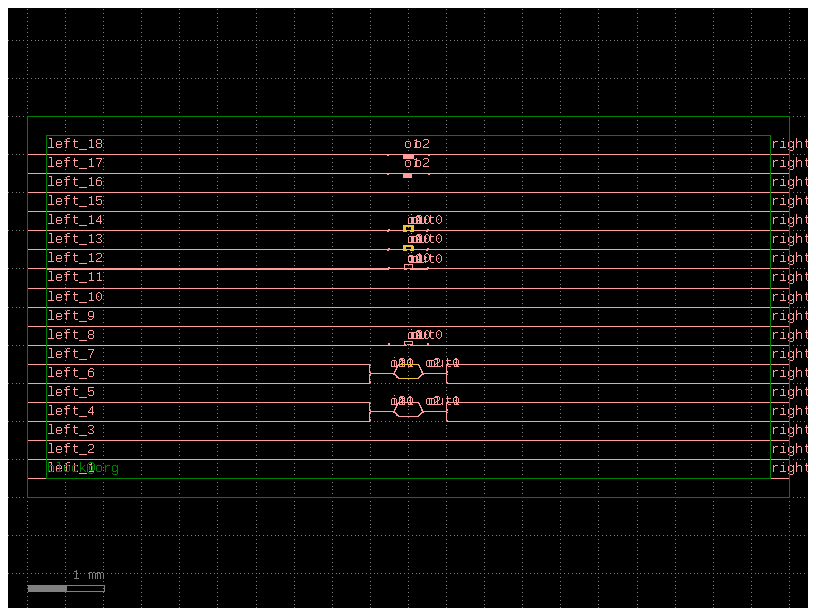

In [205]:
# LO4 c) Floorplanning and die layout

main_layout = gf.Component()

dieW = 10000
dieL = 5000
border = 250
spacing = 250

xs = gf.cross_section.strip(width=1.2, layer="WG")

die_ref = main_layout.add_ref(
    die_with_ios(
        dieW=dieW,
        dieL=dieL,
        border=border,
        spacing=spacing,
        xs="strip"
    )
)

# -----------------------------
# 1) Tres grupos de tres guías rectas
# -----------------------------

straight_indices = [1, 2, 3, 9, 10, 11, 15, 16, 17]

for index in straight_indices:

    port_in = die_ref.ports[f"left_{index}"]
    port_out = die_ref.ports[f"right_{index}"]

    length = port_out.center[0] - port_in.center[0]

    wg = main_layout.add_ref(
        gf.components.straight(
            length=length,
            cross_section=xs
        )
    )

    wg.connect(
        "o1",
        port_in,
        allow_width_mismatch=True,
        allow_layer_mismatch=True
    )


# -----------------------------
# 2) Instanciar componentes
# -----------------------------

mzi_1 = main_layout.add_ref(mzi_desbalanceado(delta_l=120))
mzi_2 = main_layout.add_ref(mzi_desbalanceado_heater(delta_l=120))

ring_1 = main_layout.add_ref(ring_allpass_mmi(extra_length=20))
ring_2 = main_layout.add_ref(ring_allpass_mmi(extra_length=50))

ring_h_1 = main_layout.add_ref(ring_allpass_mmi_heater_v3(extra_length=20))
ring_h_2 = main_layout.add_ref(ring_allpass_mmi_heater_v3(extra_length=50))

spiral_1 = main_layout.add_ref(spiral_length_cell(length=1000))
spiral_2 = main_layout.add_ref(spiral_length_cell(length=1200))


# -----------------------------
# 3) Funciones auxiliares
# -----------------------------

def move_reference(reference, dx, dy):
    reference.move((dx, dy))


def route_mzi(reference, lower_index, upper_index, target_center_x=5000):

    lower_index, upper_index = sorted([lower_index, upper_index])

    die_in_lower = die_ref.ports[f"left_{lower_index}"]
    die_in_upper = die_ref.ports[f"left_{upper_index}"]
    die_out_lower = die_ref.ports[f"right_{lower_index}"]
    die_out_upper = die_ref.ports[f"right_{upper_index}"]

    inputs = sorted(
        [reference.ports["in0"], reference.ports["in1"]],
        key=lambda p: p.center[1]
    )

    outputs = sorted(
        [reference.ports["out0"], reference.ports["out1"]],
        key=lambda p: p.center[1]
    )

    target_center_y = (
        die_in_lower.center[1] + die_in_upper.center[1]
    ) / 2

    current_center_x = (
        inputs[0].center[0] + outputs[0].center[0]
    ) / 2

    current_center_y = (
        inputs[0].center[1] + inputs[1].center[1]
    ) / 2

    move_reference(
        reference,
        target_center_x - current_center_x,
        target_center_y - current_center_y
    )

    inputs = sorted(
        [reference.ports["in0"], reference.ports["in1"]],
        key=lambda p: p.center[1]
    )

    outputs = sorted(
        [reference.ports["out0"], reference.ports["out1"]],
        key=lambda p: p.center[1]
    )

    die_inputs = [die_in_lower, die_in_upper]
    die_outputs = [die_out_lower, die_out_upper]

    x_input_fan = reference.xmin - 250
    x_output_fan = reference.xmax + 250

    for die_port, comp_port in zip(die_inputs, inputs):
        gf.routing.route_single(
            component=main_layout,
            port1=die_port,
            port2=comp_port,
            steps=[
                {"x": x_input_fan},
                {"y": comp_port.center[1]},
            ],
            radius=20,
            cross_section=xs,
        )

    for comp_port, die_port in zip(outputs, die_outputs):
        gf.routing.route_single(
            component=main_layout,
            port1=comp_port,
            port2=die_port,
            steps=[
                {"x": x_output_fan},
                {"y": die_port.center[1]},
            ],
            radius=20,
            cross_section=xs,
        )


def route_single_component(reference, io_index, target_center_x=5000):

    die_in = die_ref.ports[f"left_{io_index}"]
    die_out = die_ref.ports[f"right_{io_index}"]

    if "in0" in reference.ports:
        comp_in = reference.ports["in0"]
    elif "o1" in reference.ports:
        comp_in = reference.ports["o1"]
    else:
        comp_in = list(reference.ports)[0]

    if "out0" in reference.ports:
        comp_out = reference.ports["out0"]
    elif "out1" in reference.ports:
        comp_out = reference.ports["out1"]
    elif "o2" in reference.ports:
        comp_out = reference.ports["o2"]
    else:
        comp_out = list(reference.ports)[-1]

    current_center_x = (
        comp_in.center[0] + comp_out.center[0]
    ) / 2

    current_center_y = (
        comp_in.center[1] + comp_out.center[1]
    ) / 2

    move_reference(
        reference,
        target_center_x - current_center_x,
        die_in.center[1] - current_center_y
    )

    if "in0" in reference.ports:
        comp_in = reference.ports["in0"]
    elif "o1" in reference.ports:
        comp_in = reference.ports["o1"]
    else:
        comp_in = list(reference.ports)[0]

    if "out0" in reference.ports:
        comp_out = reference.ports["out0"]
    elif "out1" in reference.ports:
        comp_out = reference.ports["out1"]
    elif "o2" in reference.ports:
        comp_out = reference.ports["o2"]
    else:
        comp_out = list(reference.ports)[-1]

    x_input_fan = reference.xmin - 200
    x_output_fan = reference.xmax + 200

    gf.routing.route_single(
        component=main_layout,
        port1=die_in,
        port2=comp_in,
        steps=[
            {"x": x_input_fan},
            {"y": comp_in.center[1]},
        ],
        radius=20,
        cross_section=xs,
    )

    gf.routing.route_single(
        component=main_layout,
        port1=comp_out,
        port2=die_out,
        steps=[
            {"x": x_output_fan},
            {"y": die_out.center[1]},
        ],
        radius=20,
        cross_section=xs,
    )


# -----------------------------
# 4) Colocar y conectar componentes
# -----------------------------

route_mzi(mzi_1, lower_index=4, upper_index=5)
route_mzi(mzi_2, lower_index=6, upper_index=7)

route_single_component(ring_1, io_index=8)
route_single_component(ring_2, io_index=12)

route_single_component(ring_h_1, io_index=13)
route_single_component(ring_h_2, io_index=14)

route_single_component(spiral_1, io_index=17)
route_single_component(spiral_2, io_index=18)

main_layout.draw_ports()
main_layout.plot()
main_layout.show()